# Chl. vs MIOST-K v2.0.1 vs DUACS-OI

## To dos:
- [ ] land colour
- [ ] cleanign in general
- [ ] fix name particle_lon below!:

In [2]:
# --> # venv_py_eddy_tracker_05

import matplotlib.pyplot as plt 

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter#
import matplotlib.ticker as mticker
import cartopy.feature as cf
import matplotlib.gridspec as gridspec

import numpy as np
%matplotlib inline
import xarray as xr

## Loading eddy contours of that day:

In [3]:
from py_eddy_tracker.observations.observation import EddiesObservations


In [4]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes_map(title):
    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94], projection=ccrs.PlateCarree())

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    # ax.set_xlim(-6, 36.5), ax.set_ylim(30, 46)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

In [5]:
# Setting homedir 
# (to homogenize pathnames across PCs)

from pathlib import Path

# Get the user's home directory
homedir = Path.home()
print(f"Home directory: {homedir}")

Home directory: /Users/Gomez023


## MIOST:

In [6]:
a_MIOST_v201_20240402 = EddiesObservations.load_file(str(homedir) + "/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20240402.nc")
c_MIOST_v201_20240402 = EddiesObservations.load_file(str(homedir) + "/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_MIOST_v2.0.1_20240402.nc")

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'


## DUACS:

In [7]:
a_DUACS_NRT_20240402 = EddiesObservations.load_file(str(homedir) + "/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20240402.nc")
c_DUACS_NRT_20240402 = EddiesObservations.load_file(str(homedir) + "/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20240402.nc")

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'


# Adding CHL data

In [8]:
ds_chl_02 = xr.open_dataset(str(homedir) + "/Nextcloud/Projects/OSR10/Data/CMS/chlorophyll/1km/DT/202404/" + "cmems_obs-oc_med_bgc-plankton_my_l3-multi-1km_P1D_2024-04.nc")


In [12]:
field = ds_chl_02.CHL[1,:,:].squeeze()
cmap = "YlGn"
cbar_label = r'Chl. ($mg/m^3$)'
vmin = 0.05 #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 0.95 #np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)


In [13]:
ds_chl_02.time[1]

<xarray.DataArray 'time' ()>
array('2024-04-02T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2024-04-02
Attributes:
    axis:           T
    unit_long:      Seconds Since 1981-01-01
    long_name:      Time
    standard_name:  time

# Joint plot:

In [14]:
# Map boundaries
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes_map_gridspec(fig, position, title, right_gl=False, top_gl=False):
    """
    Create a map axis at the specified gridspec position with consistent styling.
    """
    ax = fig.add_subplot(position, projection=ccrs.PlateCarree())
    ax.set_xlim(lon_min_ax, lon_max_ax)
    ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold", fontsize=11)
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) #'k') #cartopy.feature.COLORS['land'])
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    if right_gl:
        gl.left_labels = False
    if top_gl:
        gl.bottom_labels = False

    return ax


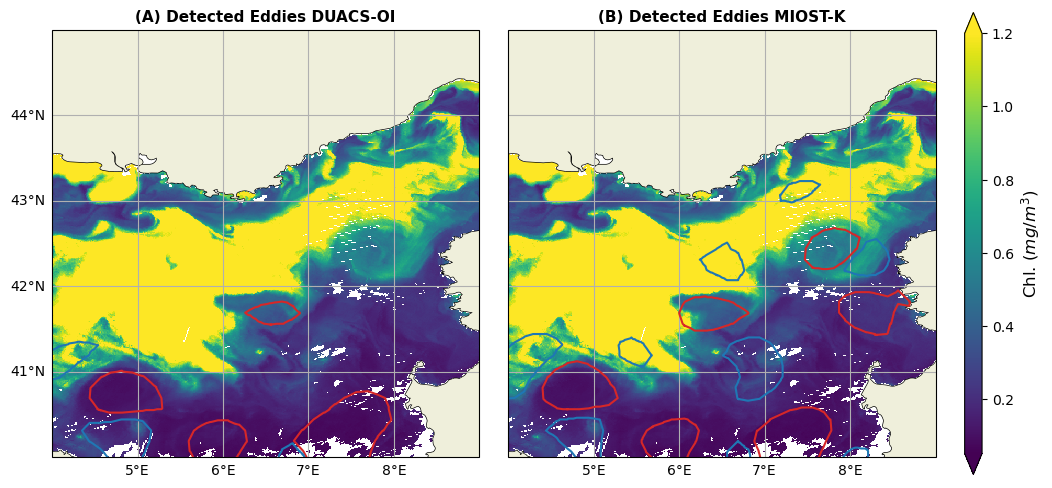

In [24]:
fig = plt.figure(figsize=(12, 6))

gs = gridspec.GridSpec(1, 3, width_ratios=[0.49, 0.49, 0.02], wspace=0.1, hspace=0.2)
cbar_ax = plt.subplot(gs[-1])

ax = start_axes_map_gridspec(fig, gs[0], f"(A) Detected Eddies DUACS-OI") #, right_gl=True)
a_DUACS_NRT_20240402.display(ax, color="C3", linewidth=1.5, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), extern_only=True, linestyle='-')
c_DUACS_NRT_20240402.display(ax, color="C0", linewidth=1.5, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), extern_only=True, linestyle='-')
cc = ax.pcolormesh(ds_chl_02.longitude, ds_chl_02.latitude, field, vmin=vmin,
    vmax=1.2, transform=ccrs.PlateCarree())
ax.set_xlim(4, 9), ax.set_ylim(40., 45.)

# ax = start_axes_map("Detected Eddies MIOST-K v1")
ax = start_axes_map_gridspec(fig, gs[1], f"(B) Detected Eddies MIOST-K", right_gl=True)
a_MIOST_v201_20240402.display(ax, color="C3", linewidth=1.5, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), extern_only=True, linestyle='-')
c_MIOST_v201_20240402.display(ax, color="C0", linewidth=1.5, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), extern_only=True, linestyle='-')
cc = ax.pcolormesh(ds_chl_02.longitude, ds_chl_02.latitude, field, vmin=vmin,
    vmax=1.2, transform=ccrs.PlateCarree())
ax.set_xlim(4, 9), ax.set_ylim(40., 45.)

cbar = plt.colorbar(cc, cax=cbar_ax, extend='both')
cbar.set_label(cbar_label, fontsize=12)
plt.show()